# 4 — Full Pipeline Integration

Tests the integrated system with both components (Bingham filter + T³ QAN) on the 2D baseline arena (not running the experiment).

In [1]:
!pip install torch numpy matplotlib
!pip install git+https://github.com/jacobsvennevik/MADE.git

  Cloning https://github.com/jacobsvennevik/MADE.git to /tmp/pip-req-build-bmk9iigk
  Running command git clone --filter=blob:none --quiet https://github.com/jacobsvennevik/MADE.git /tmp/pip-req-build-bmk9iigk
  Resolved https://github.com/jacobsvennevik/MADE.git to commit 1673eeabd571b4815122c3948694fae13de9f039
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sys.path.insert(0, '/workspace/CAN_Path_Integration_3D_model')

from network.visualize3D import visualize_trajectory_projections, plot_pi_error
from experiments.arena_2d import Arena2DExperiment, Arena2DConfig
from analysis.scoring import score_2d
from metrics import wrapped_angle_diff
from config import RunConfig, NetworkConfig, ExperimentConfig
from experiments.arena_2d import Arena2DExperiment
from analysis.scoring import score_2d_from_map
from grid_field_viz import rate_maps_from_result, plot_fields_on_floor_3d




In [3]:
# config + experiment
g_vec = np.array([0., 0., -9.81])
cfg = RunConfig(
    network=NetworkConfig(build_connectivity=False),                 # validated defaults
    experiment=Arena2DConfig(n_steps=250000), # Arena2DConfig → has run_name
)
exp = Arena2DExperiment(cfg, record=False)    # config, not g


## Set up the arena

In [4]:
scale = cfg.experiment.scale
print("scale:", scale, " speed:", cfg.experiment.speed,
      " target_speed_rad:", getattr(cfg, "target_speed_rad", None))
print("commanded theta_dot = scale*speed =", scale * cfg.experiment.speed, "rad/step")
print("ceiling = 0.0168  -> saturated?" , scale*cfg.experiment.speed > 0.0168)

scale: 13.089969389957473  speed: 0.0007639437268410976  target_speed_rad: None
commanded theta_dot = scale*speed = 0.01 rad/step
ceiling = 0.0168  -> saturated? False


In [5]:
# run + save
print("Running ...")
t0 = time.time()
result = exp.run_experiment(g=g_vec)
exp.save(result, f"workspace/runs/{cfg.experiment.run_name}.npz")
print(f"Saved runs/{cfg.experiment.run_name}.npz  ({time.time()-t0:.1f}s)")

# everything from the result object (single source of truth)
world_pos  = result.world_pos
torus_gt   = result.torus_gt
theta_hist = result.theta_hist
gap        = result.gap_hist
n_hat_hist = result.n_hat_hist
T          = cfg.experiment.n_steps

print(f"Filter gap  t=100: {gap[99]:.4f}  t=500: {gap[499]:.4f}  t={T}: {gap[-1]:.4f} ")
print(f"n_hat at t={T}: {n_hat_hist[-1]}  (target [0, 0, 1])")
print(f"theta_3 decoded range: [{theta_hist[:, 2].min():.4f}, {theta_hist[:, 2].max():.4f}]  target ~[0, 0]")
print(f"MADE error  full: {result.mean_norm_error:.4f}  after t=200: {result.norm_error[200:].mean():.4f}")

Running ...
Saved runs/arena2d_T250000_kap10.0_seed0.npz  (214.6s)
Filter gap  t=100: 506.7748  t=500: 297.4889  t=250000: 4011.0146 
n_hat at t=250000: [0. 0. 1.]  (target [0, 0, 1])
theta_3 decoded range: [0.0000, 0.0499]  target ~[0, 0]
MADE error  full: 0.0221  after t=200: 0.0217


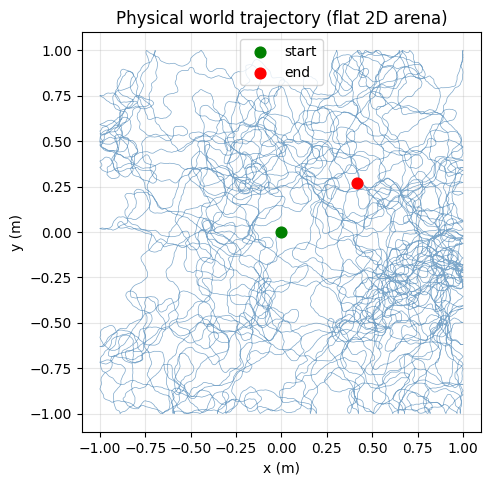

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(world_pos[:, 0], world_pos[:, 1], lw=0.5, alpha=0.7, color="steelblue")
ax.scatter(*world_pos[0, :2],  color="green", s=60, zorder=5, label="start")
ax.scatter(*world_pos[-1, :2], color="red",   s=60, zorder=5, label="end")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Physical world trajectory (flat 2D arena)")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


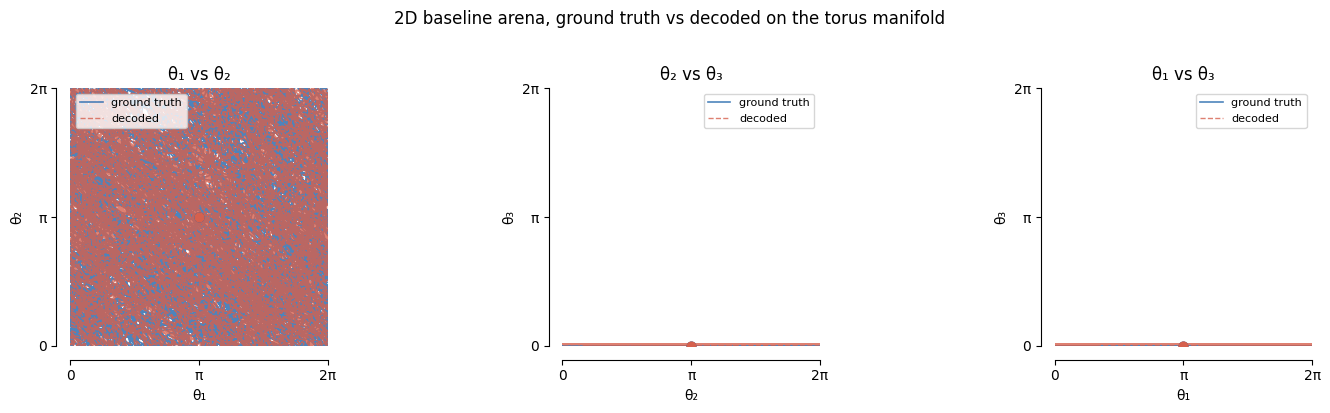

In [7]:
fig, _ = visualize_trajectory_projections(
    torus_gt, theta_hist,
    title="2D baseline arena, ground truth vs decoded on the torus manifold",
)
plt.show()


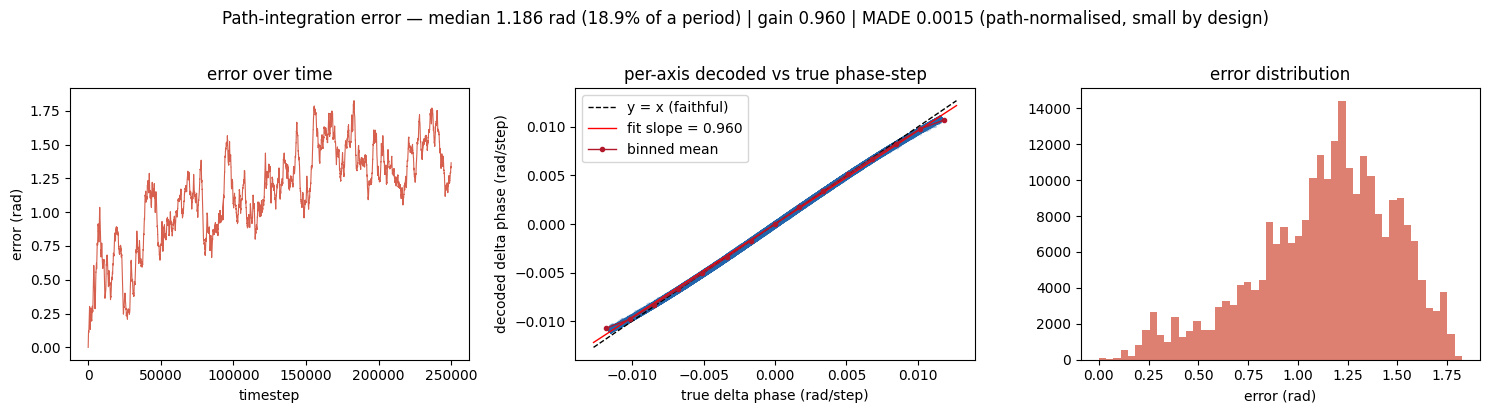

In [8]:
fig, _ = plot_pi_error(torus_gt, theta_hist)
plt.show()

Create oracle map, with perfect CAN movement to see what it produces

In [ ]:
from config import world_to_flat_bins

bins         = cfg.experiment.ratemap_bins
flat_indices = world_to_flat_bins(world_pos, cfg.experiment.env_size, bins)  # same array the harness built

bk  = exp.last_integrator.backend     # real map is already in `result`, so reusing/mutating this is safe
acc = bk.allocate_ratemap(bins)
for t in range(len(torus_gt)):
    bk.reset(torus_gt[t], radius=0.25)
    bk.record_ratemap(acc, int(flat_indices[t]))
sums_or, counts_or = bk.ratemap_to_numpy(acc, bins)

In [ ]:
def _report(tag, sums, counts):
    r  = score_2d_from_map(sums, counts)
    gl = r["grid_like"]
    print(f"{tag}: occ {r['occupancy']:.0%} | ring {r['ring_frac']:.0%} | "
          f"grid-like {gl.sum()}/{len(r['hgs'])} ({100*gl.mean():.1f}%) | "
          f"median HGS {np.nanmedian(r['hgs']):.3f} | active {r['n_active']}")
    print(f"       SGS≥HGS (square confusion): "
          f"{(np.isfinite(r['sgs']) & (r['sgs'] >= r['hgs'])).sum()} cells")
    return r

out_real   = _report("real  ", result.ratemap_sums, result.ratemap_counts)
out_oracle = _report("oracle", sums_or,             counts_or)   # best possible, no drift 100% accurate CAN

print("filter gap end:", result.gap_hist[-1], "  n_hat end:", result.n_hat_hist[-1])

In [ ]:
cell = 0
m = rate[..., cell]                       # (bins, bins) from rate_maps_from_result
bins = m.shape[0]
c = np.linspace(-1, 1, bins)
X, Y = np.meshgrid(c, c)
Z = np.nan_to_num(m.T, nan=0.0)           # transpose so x/y line up

fig = plt.figure(figsize=(4.5, 4))
ax = fig.add_subplot(111, projection="3d")
xy = result.world_pos[:, :2] / np.nanmax(np.abs(result.world_pos[:, :2]))
ax.plot(xy[:, 0], xy[:, 1], 0*xy[:, 0], color="#8fb3e6", lw=0.3, alpha=0.5)
ax.contourf(X, Y, Z, levels=12, cmap="Reds", offset=0, zdir="z")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(0, 1)
ax.set_box_aspect((1, 1, 0.7)); ax.view_init(elev=22, azim=-60)
ax.text2D(0.02, 0.95, "C", transform=ax.transAxes, fontsize=16, fontweight="bold")
plt.show()

In [ ]:
rate, _ = rate_maps_from_result(result)
fig, ax = plot_fields_on_floor_3d(rate, result.world_pos, cell=0, gain=5, power=2)
fig.savefig("panelC.png", dpi=300, bbox_inches="tight")